Iteration: 100 | Generator Loss: 8.7728 | Discriminator Loss: 0.0116
Iteration: 200 | Generator Loss: 9.1433 | Discriminator Loss: 0.0070
Iteration: 300 | Generator Loss: 5.5872 | Discriminator Loss: 0.0136
Iteration: 400 | Generator Loss: 9.3156 | Discriminator Loss: 0.0590
Iteration: 500 | Generator Loss: 8.1781 | Discriminator Loss: 0.0265
Iteration: 600 | Generator Loss: 9.7050 | Discriminator Loss: 0.0051
Iteration: 700 | Generator Loss: 9.5192 | Discriminator Loss: 0.0259
Iteration: 800 | Generator Loss: 16.5996 | Discriminator Loss: 0.0032
Iteration: 900 | Generator Loss: 7.2867 | Discriminator Loss: 0.1921
Iteration: 1000 | Generator Loss: 9.1158 | Discriminator Loss: 0.0127
Iteration: 1100 | Generator Loss: 8.2978 | Discriminator Loss: 0.0531
Iteration: 1200 | Generator Loss: 10.2894 | Discriminator Loss: 0.0057
Iteration: 1300 | Generator Loss: 7.3333 | Discriminator Loss: 0.0305
Iteration: 1400 | Generator Loss: 5.7415 | Discriminator Loss: 0.0846
Iteration: 1500 | Generator

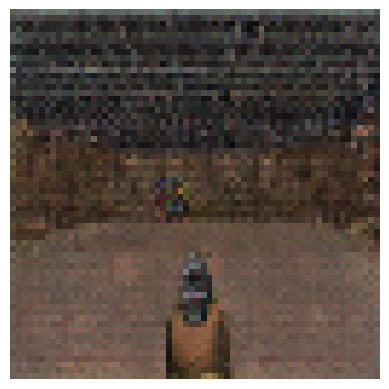

In [5]:
import gymnasium as gym 
import torch 
import torch.nn as nn 
from torch.optim import AdamW 
import numpy as np 
from vizdoom import gymnasium_wrapper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(device)
 
img_size = 64 
batch_size = 32 
latent_dim = 100
 
class Discriminator(nn.Module): 
    """ 
    Discriminator network for the GAN. 
    A CNN that takes as input rbg img from the environment. 
    """ 
    def __init__(self, optimiser = AdamW): 
        super().__init__() 
        self.layers = nn.Sequential( 
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(), 
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(128),
            nn.GELU(), 
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(256),
            nn.GELU(), 
            nn.Conv2d(in_channels=256, out_channels=512, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(512),
            nn.GELU(), 
            nn.Conv2d(in_channels=512, out_channels=1, kernel_size=4, stride=1, padding=0)
        ) 
        self.opt = optimiser(self.parameters(), weight_decay = 0.01, lr = 5e-4) 
 
    def forward(self, x): 
        return self.layers(x) 
 
class Generator(nn.Module): 
    """ 
    Generator network for the GAN. 
    A CNN that takes a latent vector as input and generates an image. 
    """ 
    def __init__(self, optimiser = AdamW): 
        super().__init__() 
        self.layers = nn.Sequential( 
            nn.ConvTranspose2d(in_channels=latent_dim, out_channels=512, kernel_size=4, stride=1, padding=0),
            nn.BatchNorm2d(512),
            nn.GELU(), 
            nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(256),
            nn.GELU(), 
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(128),
            nn.GELU(), 
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(64),
            nn.GELU(), 
            nn.ConvTranspose2d(in_channels=64, out_channels=3, kernel_size=4, stride=2, padding=1), 
            nn.Tanh()
        ) 
        self.opt = optimiser(self.parameters(), weight_decay = 0.01, lr = 5e-4) 
 
    def forward(self, x): 
        return self.layers(x) 
 
class InputWrapper(gym.ObservationWrapper): 
    """ 
    Observation wrapper for the Vizdoom environment. 
    Converts the 'screen' observation to a fixed-size float32 tensor. 
    """ 
    def __init__(self, env): 
        super().__init__(env) 
        # the observation space is a dictionary that contains screen and game variables 
        # print(env.observation_space) 
        old_space = env.observation_space['screen'] 
        # print(old_space) 
        # sanity check 
        assert isinstance(old_space, gym.spaces.Box) 
        # print(old_space.low) 
        # set boundaries, low and high are examples of min and max values as boxes, not the limits themselves 
        self.observation_space = gym.spaces.Box( 
            low = self.observation(old_space.low), 
            high = self.observation(old_space.high), 
            dtype = np.float32 
        ) 
 
    def observation(self, observation): 
        from cv2 import resize 
        # ensure the observation is in the correct format before resizing, the observation parameter isnt a dictionary only when being called in the init(), otherwise it will always be a dict 
        if isinstance(observation, dict): 
            observation = observation['screen'] 
        #print(observation) 
        # resize and move axis to be pytorch compatible then return as tensor of float 
        observation = resize(observation, (img_size, img_size)) 
        observation = np.moveaxis(observation, -1, 0) 
 
        return observation.astype(np.float32) 
 
 
def generate_data(envs: list[gym.Env]): 
    """ 
    Generate infinite batches of images from the sample environments. 
    """ 
    import random 
    global batch_size 
 
    def is_valid(observation: gym.core.ObsType) -> bool: 
        """ 
        Helper function in case we need to rid images that have only one pixel type aka black images. 
        """ 
        return np.mean(observation) > 0.1 
 
    # take initial observations (img) 
    data = [env.reset()[0] for env in envs] 
    # choose random env 
    iterator = iter(lambda: random.choice(envs), None) 
 
    while True: 
        # sample next env and a random action then get the image observation 
        env = next(iterator) 
        action = env.action_space.sample() 
        observation, reward, terminated, truncated, info = env.step(action) 
 
        if is_valid(observation): 
            data.append(observation) 
 
        # reset the environment if the episode is done 
        if terminated or truncated: 
            env.reset() 
 
        # if enough images, normalise in -1, 1 range and return then clear batch 
        if len(data) >= batch_size: 
            yield torch.tensor(np.array(data, dtype=np.float32) * 2.0 / 255.0 - 1.0) 
            data.clear() 
         
 
if __name__ == "__main__": 
    # create a list of Vizdoom environments wrapped with the InputWrapper 
    envs = [InputWrapper(gym.make(name)) for name in ["VizdoomBasic-v1", "VizdoomDeadlyCorridor-v1", "VizdoomTakeCover-v1"]] 
    shape = envs[0].observation_space.shape 
    # print(shape) 
    # initialise GAN 
    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    # use BCE WLL for the GAN loss function 
    # set maximum iterations and initialize counters and losses for the training loop 
 
    loss_func = nn.BCEWithLogitsLoss() 
    max_iter, counter = 10e3, 0 
    gen_loss, discr_loss = None, None 
 
    for batch in generate_data(envs): 
        batch = batch.to(device)
        counter += 1 
        if counter >= max_iter: 
            break 
 
        # create a random latency tensor for the generator input that follows gaussian distribution 
        # we need 32 samples, each with latent_dim channels and spatial dimensions 1x1
        latency_tensor = torch.randn(batch.shape[0], latent_dim, 1, 1, requires_grad=False, device=device) 
 
        # generate random 32img 
        generator_output = generator(latency_tensor) 
 
        # zero the grads so past iterations dont accumulate 
        discriminator.opt.zero_grad() 
 
        # generate the discriminator outputs for real and fake images 
        # .detach() is crucial since by running .backward() it would compute gradients for generator neural net too which is unwanted 
        true_img = discriminator(batch) 
        false_img = discriminator(generator_output.detach()) 
 
        # measure how well the discriminator can distinguish real from fake images 
        discr_loss = loss_func(true_img, torch.ones_like(true_img)) + loss_func(false_img, torch.zeros_like(false_img)) 
 
        # backpropagate(compute gradients) then update param 
        discr_loss.backward() 
        discriminator.opt.step() 
 
        # zero the generator grads so past iterations dont accumulate 
        generator.opt.zero_grad() 
 
        # generate the discriminator output for the fake images again 
        false_img = discriminator(generator_output) 
 
        # compute the generator loss based on how well it can fool the discriminator 
        gen_loss = loss_func(false_img, torch.ones_like(false_img)) 
        gen_loss.backward() 
        generator.opt.step() 

        if counter % 100 == 0:
            print(f"Iteration: {counter} | Generator Loss: {gen_loss.item():.4f} | Discriminator Loss: {discr_loss.item():.4f}")
        # print(f"Generator Loss: {gen_loss.item():.4f} | Discriminator Loss: {discr_loss.item():.4f}") 

import matplotlib.pyplot as plt

with torch.no_grad():
    latent_tensor = torch.randn(32, latent_dim, 1, 1, device=device)
    generated_images = generator(latent_tensor)

img = generated_images[0]


img = img.permute(1, 2, 0)


img = (img + 1) / 2
img = img.clamp(0, 1)

plt.imshow(img.cpu().numpy())
plt.axis("off")
plt.show()

In [2]:
!pip install vizdoom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.9/38.9 MB 31.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 44.1 MB/s eta 0:00:0000:0100:01
